<div style="font-family:'Times New Roman';">

**Pruebas estadísticas**

**Pruebas de abundancia diferencial para la proteómica LFQ**

1. Dependencias de carga

2. Datos de entrada

3. Prueba de abundancia diferencial

   3.1. Prueba t

   3.2. Prueba t moderada (limma)

   3.3. Prueba t moderada (DEqMS)

Existen diversas pruebas estadísticas y paquetes de R que permiten realizar pruebas de abundancia diferencial para datos proteómicos. La lista a continuación no está completa.

1. Prueba t : Si asumimos que los valores de cuantificación tienen una distribución gaussiana, una prueba t puede ser adecuada. Para LFQ, se puede asumir que las abundancias transformadas logarítmicamente tienen una distribución gaussiana. Cuando tenemos una variable de condición y comparamos dos variables de valor en un experimento LFQ (por ejemplo, muestras de tratamiento o control), una prueba t de dos muestras es adecuada.

2. Modelo ANOVA/lineal : cuando se trata de un diseño experimental más complejo, se puede utilizar un modelo ANOVA o lineal, con los mismos supuestos en la prueba t.

3. limma (Ritchie et al., 2015) : Los experimentos de proteómica suelen tener pocas réplicas (p. ej., n << 10). Por lo tanto, las estimaciones de varianza son inexactas. limmaes un paquete de R que amplía el marco de pruebas de modelos lineales/ANOVA/pruebas t para permitir el intercambio de información entre características (en este caso, proteínas) y actualizar las estimaciones de varianza. Esto reduce los falsos positivos y aumenta la potencia estadística.

4. DEqMS (Zhu et al., 2020) : Limma asume que existe una relación entre la abundancia de proteínas y la varianza. Esto suele ser así, aunque con LFQ la relación entre la varianza y el número de péptidos puede ser más fuerte.

Aquí, realizaremos análisis estadísticos sobre los datos de LFQ.

Estos son solo ejemplos y es poco probable que el código aquí incluido sea directamente aplicable a su propio conjunto de datos.

In [1]:
library(camprotR)
library(ggplot2)
library(MSnbase)
library(DEqMS)
library(limma)
library(dplyr)
library(tidyr)
library(ggplot2)
library(broom)
library(biobroom)

Warning message in fun(libname, pkgname):
"mzR has been built against a different Rcpp version (1.1.0)
than is installed on your system (1.1.1). This might lead to errors
when loading mzR. If you encounter such issues, please send a report,
including the output of sessionInfo() to the Bioc support forum at 
https://support.bioconductor.org/. For details see also
https://github.com/sneumann/mzR/wiki/mzR-Rcpp-compiler-linker-issue."
Cargando paquete requerido: BiocGenerics

Cargando paquete requerido: generics


Adjuntando el paquete: 'generics'


The following objects are masked from 'package:base':

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Adjuntando el paquete: 'BiocGenerics'


The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs


The following objects are masked from 'package:base':

    Filter, Find, Map, Position, Reduce, anyDuplicated, aperm, append,
    as.data.frame, basename, cbind, colnames,

<div style="font-family:'Times New Roman';">

Datos de entrada

Aquí, comenzaremos con los datos LFQ procesados ​​en Procesamiento de datos y control de calidad de datos LFQ . Consulte el cuaderno anterior para obtener más información sobre el diseño y el objetivo experimental, así como sobre el procesamiento de datos.

En primer lugar, leemos las proporciones de niveles de proteína obtenidas en los cuadernos anteriores.

In [2]:
lfq_protein <- readRDS('/Volumes/alex/BS_scripts_clase/proteomics-data-analysis-tutorial-master/lfq_prot_robust.rds')


<div style="font-family:'Times New Roman';">

**Prueba de abundancia diferencial**

En resumen, deseamos determinar las proteínas que se agotan significativamente mediante el tratamiento con ARNasa.

Utilizaremos tres enfoques: - prueba t pareada - prueba t pareada moderada (limma) - prueba t pareada moderada (DEqMS)

**Prueba t**

Para realizar una prueba t para cada proteína, extraemos los valores de cuantificación en un formato largo y ordenado y luego los reestructuramos para tener una columna para cada ARNasa +/-. Podemos hacerlo con el paquete biobroom.

También filtraremos las proteínas que no estén presentes en ambas muestras en al menos 3/4 de las réplicas.



In [3]:
lfq_protein_tidy <- lfq_protein %>%
  biobroom::tidy.MSnSet() %>%
  separate(sample.id, into=c(NA, 'RNase', 'replicate')) %>%
  pivot_wider(names_from=RNase, values_from=value) %>%
  filter(is.finite(neg), is.finite(pos)) %>%
  group_by(protein) %>%
  filter(length(protein)>=3)

Warning message:
"`tbl_df()` was deprecated in dplyr 1.0.0.
i Please use `tibble::as_tibble()` instead.
i The deprecated feature was likely used in the biobroom package.
  Please report the issue at <https://github.com/StoreyLab/biobroom/issues>."


<div style="font-family:'Times New Roman';">

Como ejemplo de cómo ejecutar una prueba t, subconjuntomos una sola proteína. Primero, extraemos los valores de cuantificación de esta proteína.

In [4]:
example_protein <- 'A5YKK6'

lfq_protein_tidy_example <- lfq_protein_tidy %>% filter(protein==example_protein)

print(lfq_protein_tidy_example)

# A tibble: 3 x 4
# Groups:   protein [1]
  protein replicate   neg   pos
  <chr>   <chr>     <dbl> <dbl>
1 A5YKK6  1          20.3  19.9
2 A5YKK6  2          20.4  19.6
3 A5YKK6  3          20.1  19.9


<div style="font-family:'Times New Roman';">

Luego, realizamos t.testla prueba t. Damos dos vectores de valores y el interruptor paired=TRUEpara realizar una prueba t de dos muestras pareadas.

In [5]:
t.test.example <- t.test(
  lfq_protein_tidy_example$pos,
  lfq_protein_tidy_example$neg,
  alternative='two.sided',
  var.equal=FALSE,
  paired=TRUE)

print(t.test.example)


	Paired t-test

data:  lfq_protein_tidy_example$pos and lfq_protein_tidy_example$neg
t = -3.1641, df = 2, p-value = 0.08704
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -1.1133965  0.1697793
sample estimates:
mean difference 
     -0.4718086 



<div style="font-family:'Times New Roman';">

Podemos usar tidyel broompaquete para devolver los resultados de la prueba t en un tibble ordenado. Su valor se verá en el siguiente fragmento de código.



In [6]:
head(broom::tidy(t.test.example))

estimate,statistic,p.value,parameter,conf.low,conf.high,method,alternative
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
-0.4718086,-3.164069,0.08704294,2,-1.113397,0.1697793,Paired t-test,two.sided


<div style="font-family:'Times New Roman';">

Ahora podemos aplicar una prueba t a cada proteína usando dplyr groupy do, haciendo uso de tidy.



In [7]:
t.test.all <- lfq_protein_tidy %>%
  group_by(protein) %>%
  do(tidy(t.test(.$pos, .$neg, paired=TRUE, alternative='two.sided')))


<div style="font-family:'Times New Roman';">

Aquí se muestran los resultados de la prueba t para la proteína de ejemplo. Como podemos ver, la columna "estimación" t.text.res.all representa el cociente log² de la media. La columna "estadístico" representa el estadístico t y la columna "parámetro" representa los grados de libertad del estadístico t. Todos los valores son idénticos, ya que se realizó la misma prueba con ambos métodos.

In [8]:
print(t.test.example)



	Paired t-test

data:  lfq_protein_tidy_example$pos and lfq_protein_tidy_example$neg
t = -3.1641, df = 2, p-value = 0.08704
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -1.1133965  0.1697793
sample estimates:
mean difference 
     -0.4718086 



In [9]:
t.test.all %>% filter(protein==example_protein)

protein,estimate,statistic,p.value,parameter,conf.low,conf.high,method,alternative
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
A5YKK6,-0.4718086,-3.164069,0.08704294,2,-1.113397,0.1697793,Paired t-test,two.sided


<div style="font-family:'Times New Roman';">

Al realizar muchas pruebas estadísticas simultáneamente, se recomienda graficar la distribución del valor p. Si los supuestos de la prueba son válidos, se espera una distribución uniforme de 0 a 1 para aquellas pruebas en las que no se debe rechazar la hipótesis nula. Las pruebas estadísticamente significativas se mostrarán como un pico con valores p muy bajos. Si existen sesgos muy claros en la distribución uniforme, o picos inusuales fuera del intervalo más pequeño del valor p, esto podría indicar que los supuestos de la prueba no son válidos para algunas o todas las pruebas.

Hay un pico claro para valores p muy bajos (<0,05) y una distribución aproximadamente uniforme en el resto del rango de valores p, que es lo que queremos.

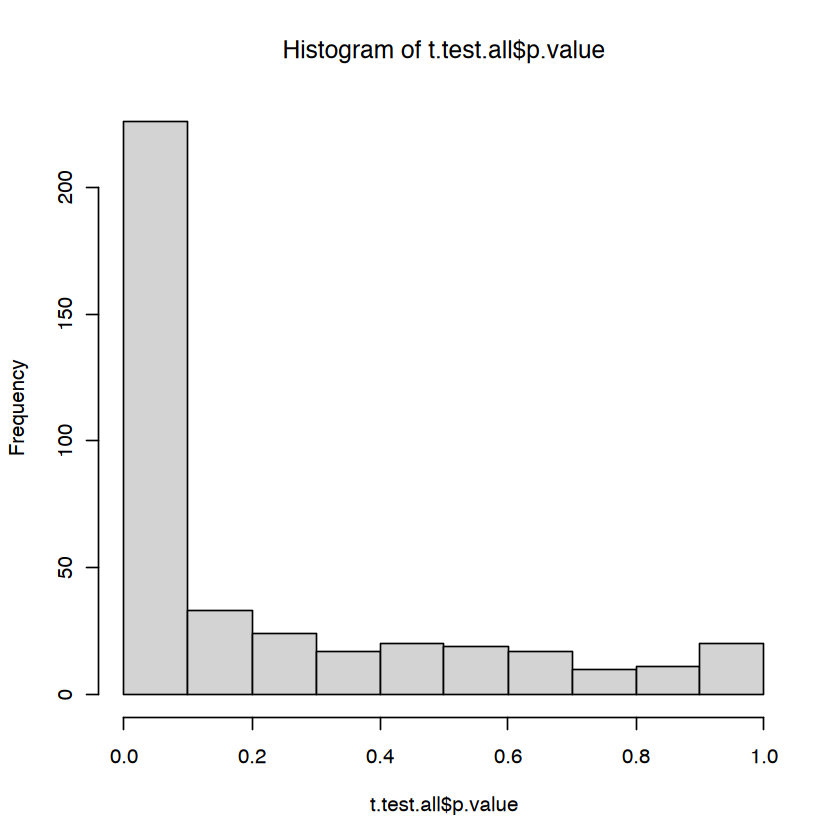

In [10]:
hist(t.test.all$p.value)


<div style="font-family:'Times New Roman';">

pruebas, queremos calcular un valor p ajustado para evitar errores de tipo I (falsos positivos).

Aquí, utilizamos el método de Benjamini, Y. y Hochberg, Y. (1995) para estimar la tasa de falsos descubrimientos, es decir, la proporción de falsos positivos entre las hipótesis nulas rechazadas.

In [13]:
t.test.all$padj <- p.adjust(t.test.all$p.value, method='BH')
#hist(t.test.all$padj)

<div style="font-family:'Times New Roman';">

Con un FDR del 1%, tenemos 0 proteínas con una diferencia significativa.



In [14]:
sum(t.test.all$padj<0.01)


[1] 0

<div style="font-family:'Times New Roman';">

**Prueba t moderada (limma)**

Los experimentos de proteómica suelen tener pocas réplicas (p. ej., n << 10). Por lo tanto, las estimaciones de varianza son inexactas. limma (Ritchie et al., 2015) es un paquete de R que amplía el marco de pruebas de modelos lineales/ANOVA/pruebas t para permitir el intercambio de información entre características (en este caso, proteínas) y actualizar las estimaciones de varianza. Esto reduce los falsos positivos y aumenta la potencia estadística.

Primero reconstruiremos un MSnset a partir de nuestros datos filtrados, ya que es más fácil trabajar con limma usando este objeto proteómico estándar.



In [15]:
filtered_exprs <- lfq_protein_tidy %>%
  pivot_longer(cols=c(neg, pos), names_to='RNase') %>%
  mutate(sample=paste0('RNase_', RNase, '.', replicate)) %>%
  pivot_wider(names_from=sample, values_from=value, id_cols=protein) %>%
  tibble::column_to_rownames('protein') %>%
  as.matrix()

filtered_lfq_protein <- MSnSet(exprs=filtered_exprs,
                               fData=fData(lfq_protein)[rownames(filtered_exprs),],
                               pData=pData(lfq_protein)[colnames(filtered_exprs),])

<div style="font-family:'Times New Roman';">

A continuación, creamos el MArrayLM objeto y un modelo de diseño. Los proporcionamos para limma::lmFit ajustar el modelo lineal según el diseño y, posteriormente, los usamos limma::eBayespara calcular las estadísticas de prueba moderadas.

In [16]:
exprs_for_limma <- exprs(filtered_lfq_protein)

# Performing the equivalent of a two-sample t-test
condition <- pData(filtered_lfq_protein)$Condition
replicate <- pData(filtered_lfq_protein)$Replicate

limma_design <- model.matrix(formula(~replicate+condition))

limma_fit <- lmFit(exprs_for_limma, limma_design)
limma_fit <- eBayes(limma_fit, trend=TRUE)

<div style="font-family:'Times New Roman';">

Podemos visualizar la relación entre la abundancia promedio y la varianza utilizando la limma::plotSA función.



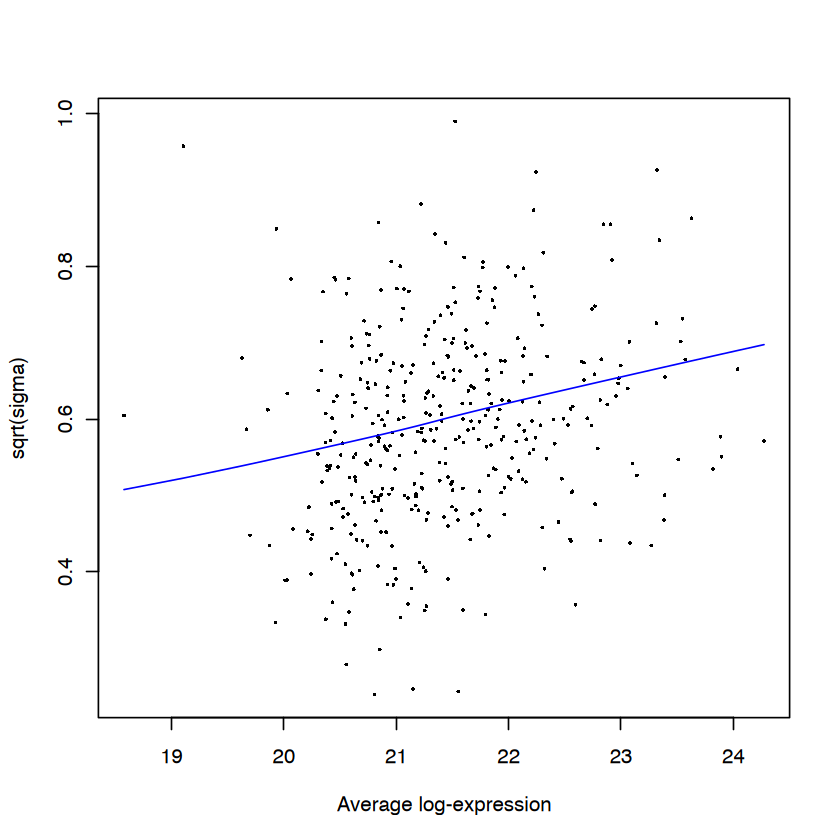

In [17]:
limma::plotSA(limma_fit)


<div style="font-family:'Times New Roman';">

A pesar de la falta de una relación sólida entre la abundancia de proteínas y la varianza, continuaremos con limma, ya que seguirá aumentando los grados de libertad efectivos con los que se estiman las varianzas gen por gen. En este caso, las varianzas se reducirán hacia un valor similar, independientemente de la abundancia media de proteínas.

Podemos extraer una tabla de resultados como esta



In [18]:

# use colnames(limma_fit$coefficients) to identify the coefficient names
limma_results <- topTable(limma_fit, n=Inf, coef='conditionRNase_pos')

<div style="font-family:'Times New Roman';">

A continuación, resumimos la cantidad de proteínas con abundancia estadísticamente diferente en CL vs NC y trazamos un gráfico de "volcán" para visualizarlo.

In [19]:
table(limma_results$adj.P.Val<0.01)


FALSE  TRUE 
  261   136 

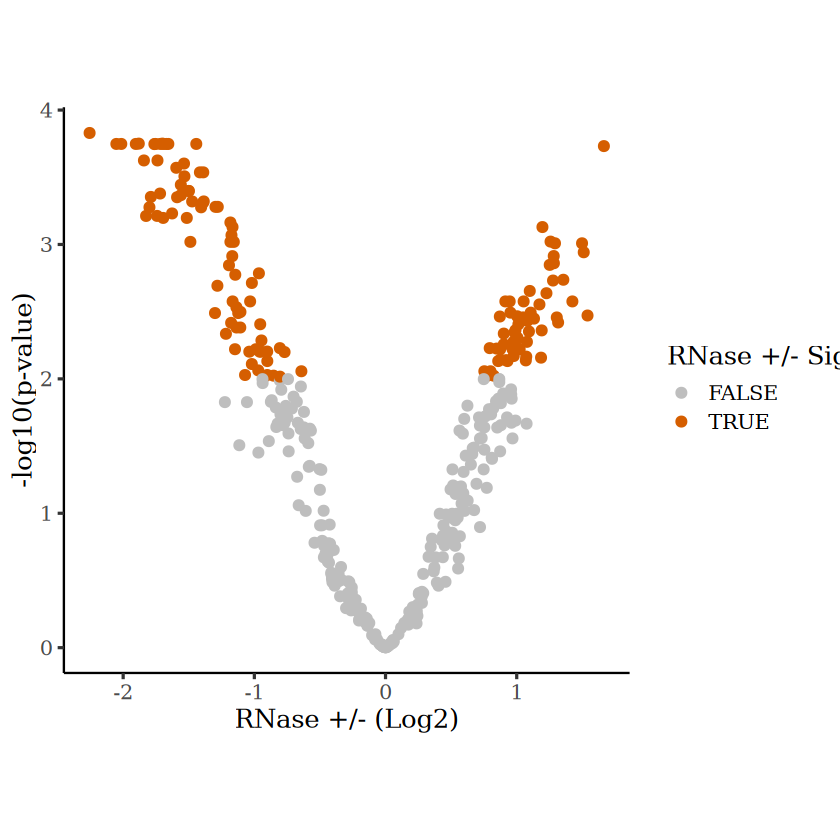

In [20]:
limma_results %>%
  ggplot(aes(x = logFC, y = -log10(adj.P.Val), colour = adj.P.Val < 0.01)) +
  geom_point() +
  theme_camprot(border=FALSE, base_size=15) +
  scale_colour_manual(values = c('grey', get_cat_palette(2)[2]), name = 'RNase +/- Sig.') +
  labs(x = 'RNase +/- (Log2)', y = '-log10(p-value)')

<div style="font-family:'Times New Roman';">

**Discusión 1**
Dado el diseño experimental, ¿esperaría que las proteínas tuvieran cambios significativos en ambas direcciones?
¿Cómo interpretarías los cambios de plegamiento identificados con respecto a las abundancias absolutas de proteínas?

<div style="font-family:'Times New Roman';">

1. Partimos de una única interfaz OOPS y añadimos +/- RNasa, para luego volver a recoger la interfaz. Las RBP deberían agotarse, pero no hay forma de que ninguna proteína se enriquezca con este proceso. Por lo tanto, ¡no esperaríamos proteínas con una relación RNasa +/- positiva!
2. Las abundancias de proteínas son relativas a la cantidad total de proteínas en cada muestra. Por lo tanto, los cambios en el pliegue son relativos al cambio global en el pliegue de la cantidad de proteínas en cada muestra. Por ejemplo, si hay una pérdida global de proteínas en las muestras RNasa +, una relación RNasa +/- positiva solo representa un aumento relativo a la pérdida global, ¡y podría ser una relación RNasa +/- negativa en términos absolutos!
3. Estamos observando ratios RNasa +/- positivos porque hay una diferencia global en la cantidad de proteína y estamos utilizando un enfoque de cuantificación de la abundancia relativa de proteínas.


<div style="font-family:'Times New Roman';">

Ahora podemos comparar los resultados de la prueba t y la prueba t moderada (limma). A continuación, actualizamos los nombres de las columnas para que sea más fácil identificar qué columna proviene de cada prueba y, a continuación, fusionamos los resultados de ambas pruebas.


In [21]:
lfq_compare_tests <- merge(
  setNames(limma_results, paste0('limma.', colnames(limma_results))),
  setNames(t.test.all, paste0('t.test.', colnames(t.test.all))),
  by.x='row.names',
  by.y='t.test.protein')

<div style="font-family:'Times New Roman';">

Ejercicio

Compare las estimaciones del tamaño del efecto de la prueba t con las de las pruebas t moderadas. ¿Puede explicar lo que observa?

Consejos:

Para la prueba t, desea la columna 't.test.estimate'

Para la prueba t moderada, puede utilizar la columna 'limma.logFC'

Solución:

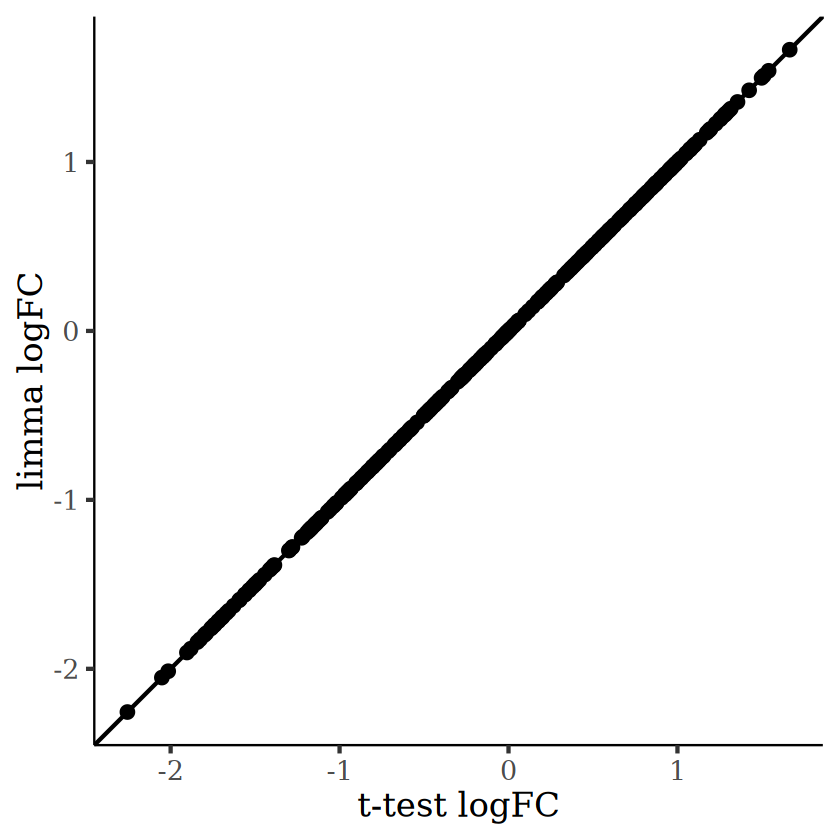

In [22]:
ggplot(lfq_compare_tests) +
  aes(t.test.estimate, limma.logFC) +
  geom_point() +
  geom_abline(slope=1) +
  theme_camprot(border=FALSE) +
  labs(x='t-test logFC', y='limma logFC')

<div style="font-family:'Times New Roman';">

También podemos comparar los valores p de ambas pruebas. Cabe destacar que el valor p es casi siempre menor para la prueba t moderada limmaque para la prueba t estándar.

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
i Please use `linewidth` instead."


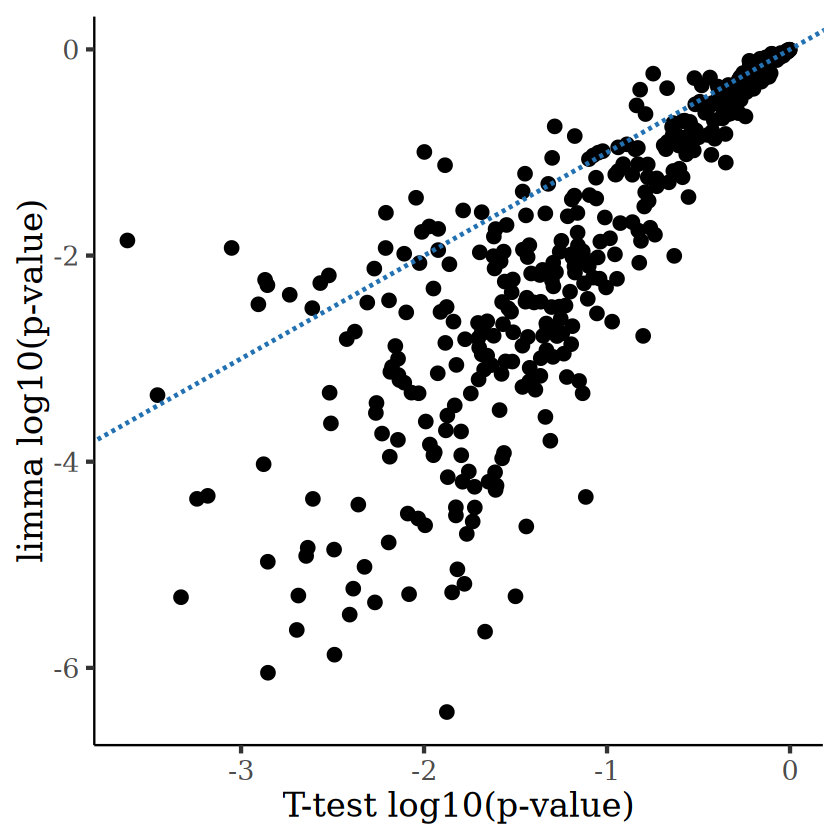

In [23]:
p <- ggplot(lfq_compare_tests) +
  aes(log10(t.test.p.value), log10(limma.P.Value)) +
  geom_point() +
  geom_abline(slope=1, linetype=2, colour=get_cat_palette(1), size=1) +
  theme_camprot(border=FALSE) +
  labs(x='T-test log10(p-value)', y='limma log10(p-value)')


print(p)

<div style="font-family:'Times New Roman';">

Finalmente, podemos comparar el número de proteínas con una diferencia significativa (utilizando un umbral de FDR del 1%) según cada prueba. Mediante la prueba t, no se encontraron diferencias significativas, pero con Limma, 182 proteínas presentan una diferencia significativa.

In [24]:
lfq_compare_tests %>%
  group_by(t.test.padj<0.01,
           limma.P.Value<0.01) %>%
  tally()

t.test.padj < 0.01,limma.P.Value < 0.01,n
<lgl>,<lgl>,<int>
FALSE,FALSE,214
FALSE,TRUE,183


<div style="font-family:'Times New Roman';">

**Prueba t moderada (DEqMS)**

Limma asume que existe una relación entre la abundancia de proteínas y la varianza. Esto suele ser así, aunque hemos visto anteriormente que no es así con nuestros datos. En el caso de LFQ, la relación entre la varianza y el número de péptidos puede ser más fuerte.

DEqMS (Zhu et al. 2020) es una alternativa a limma, que puede considerarse como una extensión de limma (Ritchie et al. 2015) específicamente para la proteómica, que utiliza la cantidad de péptidos en lugar de la abundancia media para compartir información entre proteínas.

Los pasos del análisis se toman de la viñeta DEqMS . Partimos de lo que MArrayLMcreamos para limmael análisis y, a continuación, simplemente añadimos una $count columna al MArrayLMobjeto y usamos la spectraCounteBayesfunción para realizar la contracción bayesiana utilizando la columna de recuento, que describe el número de péptidos por proteína. Esto contrasta con [texto incoherente] limma, que utiliza la $Ameancolumna que describe la abundancia media de proteínas.

Para definir la $countcolumna, necesitamos resumir el número de péptidos por proteína. En el artículo de DEqMS, se sugiere que la mejor métrica de resumen es el valor mínimo en las muestras, por lo que nuestra countcolumna es el número mínimo de péptidos por proteína.

In [26]:
filtered_lfq_protein_long <- filtered_lfq_protein %>%
  exprs() %>%
  data.frame() %>%
  tibble::rownames_to_column('Master.Protein.Accessions') %>%
  pivot_longer(cols=-Master.Protein.Accessions, values_to='abundance', names_to='sample')

lfq_pep_res <- readRDS('/Volumes/alex/BS_scripts_clase/proteomics-data-analysis-tutorial-master/lfq_pep_restricted.rds')

# Obtain the min peptide count across the samples and determine the minimum value across
# samples
min_pep_count <- camprotR::count_features_per_protein(lfq_pep_res) %>%
  merge(filtered_lfq_protein_long, by=c('Master.Protein.Accessions', 'sample')) %>%
  filter(is.finite(abundance)) %>%  # We only want to consider samples with a ratio quantified
  group_by(Master.Protein.Accessions) %>%
  summarise(min_pep_count = min(n))

# add the min peptide count
limma_fit$count <- min_pep_count$min_pep_count

<div style="font-family:'Times New Roman';">

Y ahora pasamos spectraCounteBayes a DEqMS para realizar la prueba estadística.



In [27]:
# run DEqMS
efit_deqms <- suppressWarnings(spectraCounteBayes(limma_fit))

<div style="font-family:'Times New Roman';">

A continuación, inspeccionamos la relación entre el recuento de péptidos y la varianza que DEqMSse utiliza en la prueba estadística.

En este caso, la relación entre el recuento de péptidos y la varianza no está del todo clara. De todas formas, seguimos adelante. Al igual que con el análisis de limma, la varianza se reducirá hacia una media global en lugar de una basada en el número de péptidos.

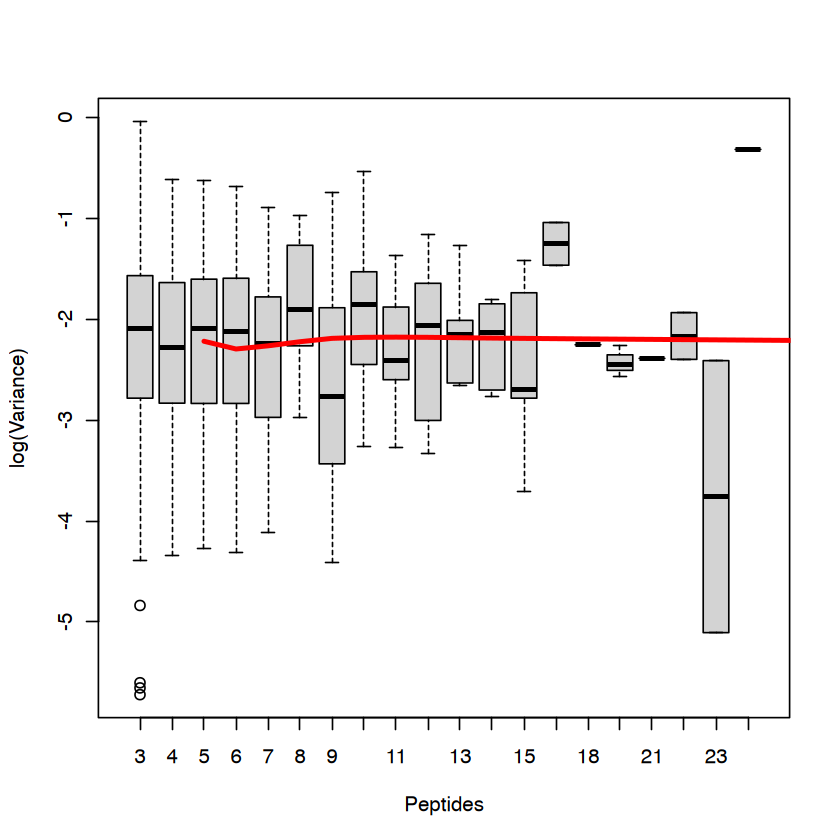

In [28]:
# Diagnostic plots
VarianceBoxplot(efit_deqms, n = 30, xlab = "Peptides")

<div style="font-family:'Times New Roman';">

A continuación, resumimos el número de proteínas con abundancia estadísticamente diferente en ARNasa +/- y trazamos un gráfico de "volcán" para visualizarlo.


FALSE  TRUE 
  267   130 

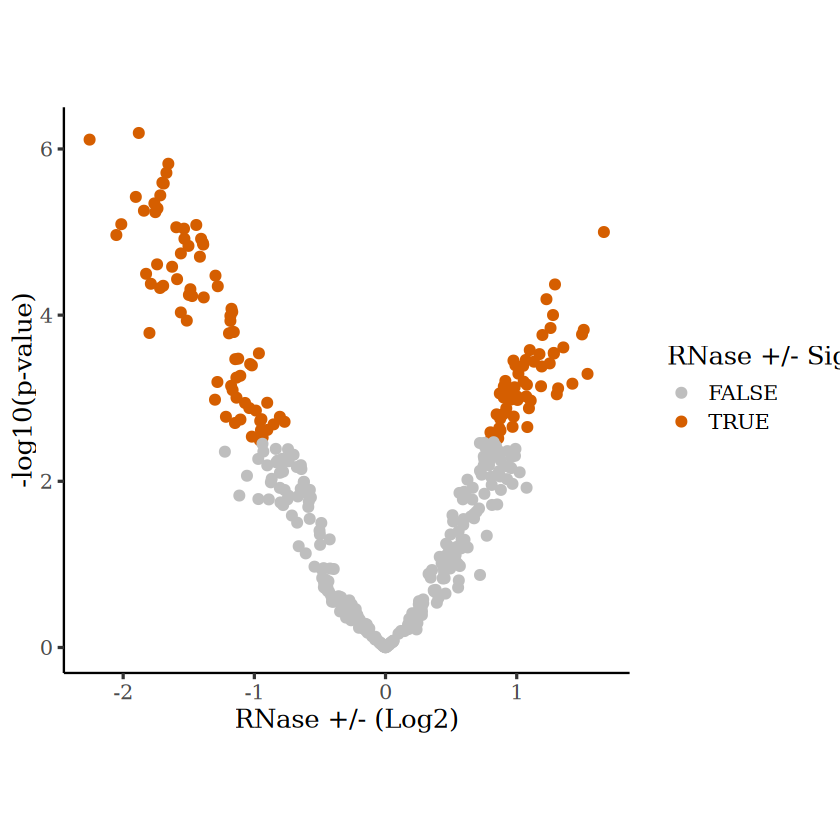

In [29]:
deqms_results <- outputResult(efit_deqms, coef_col=3)


table(deqms_results$sca.adj.pva<0.01)
#> 
#> FALSE  TRUE 
#>   267   130


deqms_results %>%
  ggplot(aes(x = logFC, y = -log10(sca.P.Value), colour = sca.adj.pval < 0.01)) +
  geom_point() +
  theme_camprot(border=FALSE, base_size=15) +
  scale_colour_manual(values = c('grey', get_cat_palette(2)[2]), name = 'RNase +/- Sig.') +
  labs(x = 'RNase +/- (Log2)', y = '-log10(p-value)')

<div style="font-family:'Times New Roman';">

DEqMS considerando el número de diferencias significativas. Nótese que los resultados de limma también se incluyen con los de DEqMS. Las columnas $t, $P.Valuey $adj.P.Valson de limma. Las columnas con el prefijo scason de DEqMS.



In [30]:
deqms_results %>%
  group_by(limma_sig=adj.P.Val<0.01,
           DEqMS_sig=sca.adj.pval<0.01) %>%
  tally()

limma_sig,DEqMS_sig,n
<lgl>,<lgl>,<int>
FALSE,FALSE,256
FALSE,TRUE,5
TRUE,FALSE,11
TRUE,TRUE,125


<div style="font-family:'Times New Roman';">

Podemos comparar los resultados de limma y DEqMS considerando los valores p. Cabe destacar que, en este caso, presentan una excelente correlación. Esto se debe a que los métodos no lograron identificar una tendencia clara entre la abundancia media (limma) o el número de péptidos (DEqMS) y la varianza. Por lo tanto, ambos métodos redujeron la varianza hacia una media global y, de forma similar, aumentaron los grados de libertad efectivos.

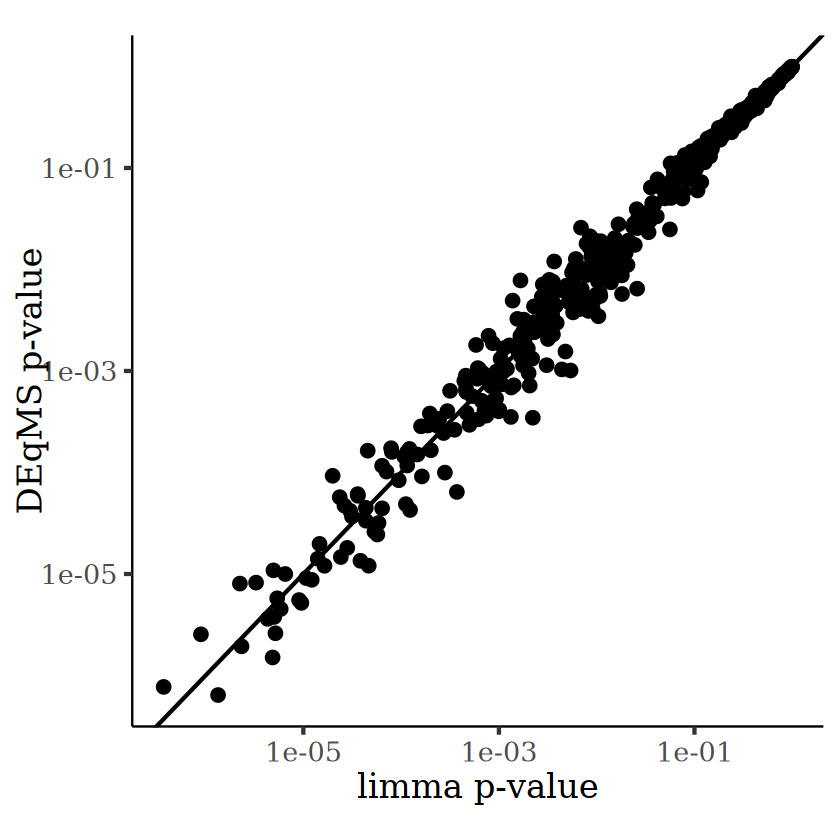

In [31]:
deqms_results %>%
  ggplot() +
  aes(P.Value, sca.P.Value) +
  geom_point() +
  geom_abline(slope=1) +
  theme_camprot(border=FALSE) +
  labs(x='limma p-value', y='DEqMS p-value') +
  scale_x_log10() +
  scale_y_log10()

<div style="font-family:'Times New Roman';">

Finalmente, en este punto podemos guardar cualquiera de los archivos data.framesque contienen los resultados de las pruebas estadísticas, ya sea en un formato comprimido ( rds) para leerlo posteriormente en un cuaderno R, o en un archivo plano ( .tsv) para leerlo con, por ejemplo, Excel.



In [32]:
# These lines are not run and are examples only

saveRDS(deqms_results, '/Volumes/alex/BS_scripts_clase/proteomics-data-analysis-tutorial-master/filename_to_save_to.rds')
write.csv(deqms_results, '/Volumes/alex/BS_scripts_clase/proteomics-data-analysis-tutorial-master/filename_to_save_to.tsv', sep='\t', row.names=FALSE)

Warning message in write.csv(deqms_results, "/Volumes/alex/BS_scripts_clase/proteomics-data-analysis-tutorial-master/filename_to_save_to.tsv", :
"attempt to set 'sep' ignored"
